In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### ANALISIS BAJAS

In [151]:
df = pd.read_excel("pronostico.xlsx", sheet_name='BAJAS')
df.head()

,DIA,MES,ANIO,BAJAS
0,1,8,2025,16858
1,2,8,2025,18556
2,3,8,2025,17043
3,4,8,2025,19431
4,5,8,2025,18429


In [152]:
df['FECHA'] = pd.to_datetime(df['ANIO'].astype(str) + '-' +
                             df['MES'].astype(str) + '-' +
                             df['DIA'].astype(str))



In [153]:
df.dtypes

DIA               int64
MES               int64
ANIO              int64
BAJAS             int64
FECHA    datetime64[us]
dtype: object

In [154]:
df = df.set_index('FECHA')

In [155]:
ago2026= df[(df['ANIO']==2026) & (df['MES']==8)]

In [156]:
ago2026.head()

,DIA,MES,ANIO,BAJAS
FECHA,,,,
2026-08-01,1,8,2026,19109
2026-08-02,2,8,2026,19955
2026-08-03,3,8,2026,19012
2026-08-04,4,8,2026,19322
2026-08-05,5,8,2026,17076


### agosto 2026 vs agosto 2025

In [157]:
ago2025= df[(df['ANIO']==2025) & (df['MES']==8)]

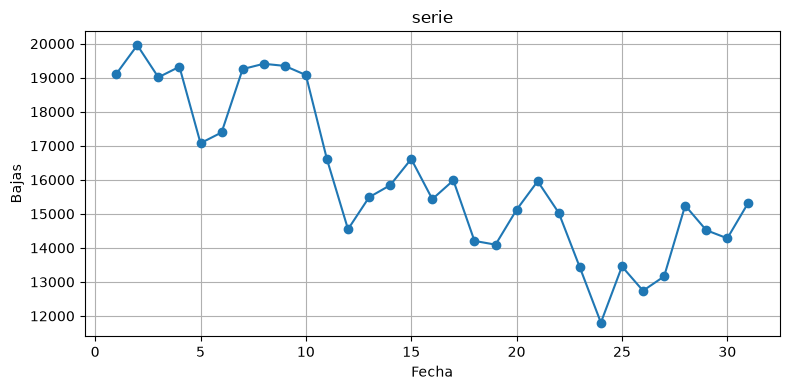

In [158]:
plt.figure(figsize=(8, 4))
ago2026.set_index(ago2026['DIA'])['BAJAS'].plot(
    marker='o', linestyle='-', label='Agosto 2026')
plt.title('serie')
plt.xlabel('Fecha')
plt.ylabel('Bajas')
plt.grid(True)
plt.tight_layout()
plt.show()

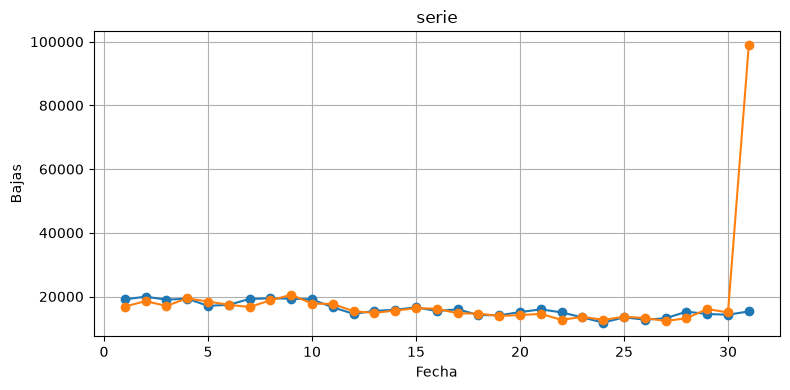

In [159]:
plt.figure(figsize=(8, 4))
ago2026.set_index(ago2026['DIA'])['BAJAS'].plot(
    marker='o', linestyle='-', label='Agosto 2026'
)
ago2025.set_index(ago2025['DIA'])['BAJAS'].plot(
    marker='o', linestyle='-', label='Agosto 2025'
)
plt.title('serie')
plt.xlabel('Fecha')
plt.ylabel('Bajas')
plt.grid(True)
plt.tight_layout()
plt.show()

## PROYECCION

In [160]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [161]:
periodo = 30
resultado = seasonal_decompose(df['BAJAS'], model='additive', period=periodo)

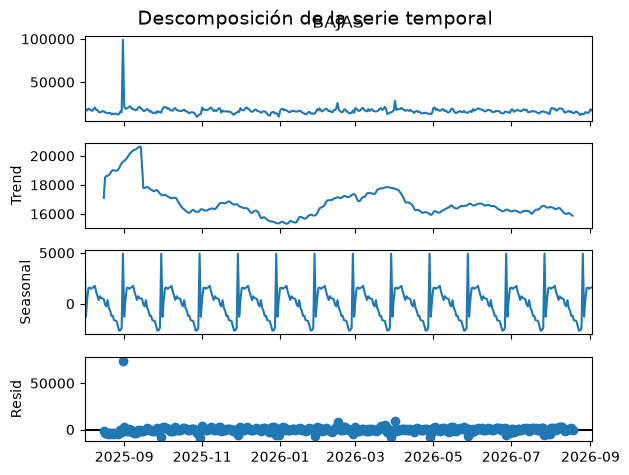

In [162]:
resultado.plot()
plt.suptitle("Descomposición de la serie temporal", fontsize=14)
plt.show()

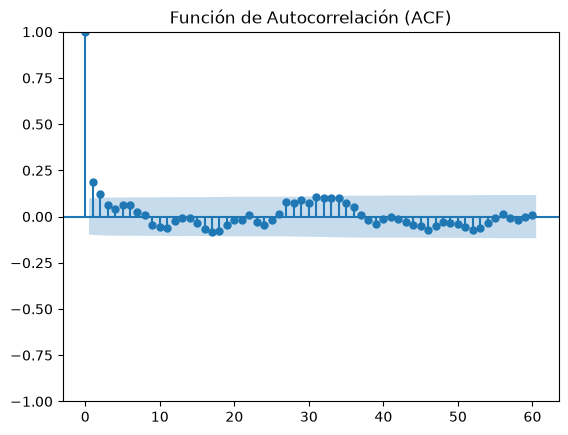

In [163]:

plot_acf(df['BAJAS'].dropna(), lags=60)
plt.title("Función de Autocorrelación (ACF)")
plt.show()

In [164]:
adf_result = adfuller(df['BAJAS'].dropna())
adf_stat, p_value = adf_result[0], adf_result[1]

print(f"Estadístico ADF: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Estadístico ADF: -11.5400
p-value: 0.0000


C:\Users\lapupalj\AppData\Local\Temp\ipykernel_8236\2193892048.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df['BAJAS'].dropna())



## la serie es estacionaria no tiene tendencia 


In [165]:
from prophet import Prophet

In [166]:
df['FECHA'] = pd.to_datetime(df['ANIO'].astype(str) + '-' +
                             df['MES'].astype(str) + '-' +
                             df['DIA'].astype(str))



In [167]:
df_prophet = df[['FECHA', 'BAJAS']].copy()

In [168]:
df_prophet = df_prophet.rename(columns={
    'FECHA': 'ds',
    'BAJAS': 'y'
})

In [169]:
df_prophet = df_prophet.sort_values('ds')

In [170]:
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(df_prophet)

16:59:31 - cmdstanpy - INFO - Chain [1] start processing
16:59:31 - cmdstanpy - INFO - Chain [1] done processing


In [171]:
future_sep = pd.DataFrame({
    'ds': pd.date_range(
        start='2026-09-01',
        end='2026-09-30',
        freq='D'
    )
})

In [172]:
forecast_sep =model.predict(future_sep)

In [173]:
print(forecast_sep[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

           ds          yhat    yhat_lower    yhat_upper
0  2026-09-01  15118.548800   9499.676149  21124.363162
1  2026-09-02  15104.240192   9220.732721  20686.618117
2  2026-09-03  15321.633471   9700.351766  21448.764843
3  2026-09-04  16537.704894  10802.549127  22160.523274
4  2026-09-05  17008.925967  11000.534860  22394.696484
5  2026-09-06  17496.410362  11999.734088  23051.980604
6  2026-09-07  16124.613100  10495.267302  22103.653966
7  2026-09-08  15103.041070   9162.250578  21024.369008
8  2026-09-09  15088.732462   9131.557547  21303.205009
9  2026-09-10  15306.125741   9327.996079  21230.845841
10 2026-09-11  16522.197164  10178.912238  22178.709040
11 2026-09-12  16993.418237  11012.163573  22723.442350
12 2026-09-13  17480.902632  11583.659871  23041.926618
13 2026-09-14  16109.105370  10177.067504  21652.991885
14 2026-09-15  15087.533340   9221.141780  20748.184090
15 2026-09-16  15073.224731   9229.496847  21035.675105
16 2026-09-17  15290.618011   9445.008390  20937

In [174]:
forecast_sep['yhat'].sum()

np.float64(480295.7096310548)

In [175]:
df_adj = forecast_sep[['ds', 'yhat']].copy()


In [176]:
n = len(df_adj)
pesos = np.linspace(1.20, 0.80, n)  

df_adj['yhat_ponderado'] = df_adj['yhat'] * pesos

objetivo = 486_000
factor = objetivo / df_adj['yhat_ponderado'].sum()
df_adj['yhat_ajustado'] = df_adj['yhat_ponderado'] * factor

print(df_adj[['ds', 'yhat', 'yhat_ajustado']])
print("Suma ajustada:", df_adj['yhat_ajustado'].sum())

           ds          yhat  yhat_ajustado
0  2026-09-01  15118.548800   18360.541878
1  2026-09-02  15104.240192   18132.323982
2  2026-09-03  15321.633471   18179.424479
3  2026-09-04  16537.704894   19391.466744
4  2026-09-05  17008.925967   19706.573569
5  2026-09-06  17496.410362   20027.140484
6  2026-09-07  16124.613100   18231.838177
7  2026-09-08  15103.041070   16865.939034
8  2026-09-09  15088.732462   16639.335754
9  2026-09-10  15306.125741   16665.410485
10 2026-09-11  16522.197164   17758.842736
11 2026-09-12  16993.418237   18028.121417
12 2026-09-13  17480.902632   18301.271042
13 2026-09-14  16109.105370   16640.228198
14 2026-09-15  15087.533340   15374.366816
15 2026-09-16  15073.224731   15149.378153
16 2026-09-17  15290.618011   15154.427118
17 2026-09-18  16506.689434   16129.249355
18 2026-09-19  16977.910507   16352.699890
19 2026-09-20  17465.394902   16578.432225
20 2026-09-21  16093.597640   15051.648845
21 2026-09-22  15072.025609   13885.825225
22 2026-09-

In [177]:
df_adj.head(30)

,ds,yhat,yhat_ponderado,yhat_ajustado
0,2026-09-01,15118.548800,18142.258560,18360.541878
1,2026-09-02,15104.240192,17916.753883,18132.323982
2,2026-09-03,15321.633471,17963.294415,18179.424479
3,2026-09-04,16537.704894,19160.927050,19391.466744
4,2026-09-05,17008.925967,19472.287659,19706.573569
5,2026-09-06,17496.410362,19789.043444,20027.140484
6,2026-09-07,16124.613100,18015.084981,18231.838177
7,2026-09-08,15103.041070,16665.424629,16865.939034
8,2026-09-09,15088.732462,16441.515372,16639.335754
9,2026-09-10,15306.125741,16467.280108,16665.410485


In [178]:
df_adj['yhat'].sum()
df_adj['yhat_ponderado'].sum()
df_adj['yhat_ajustado'].sum()

np.float64(485999.99999999994)

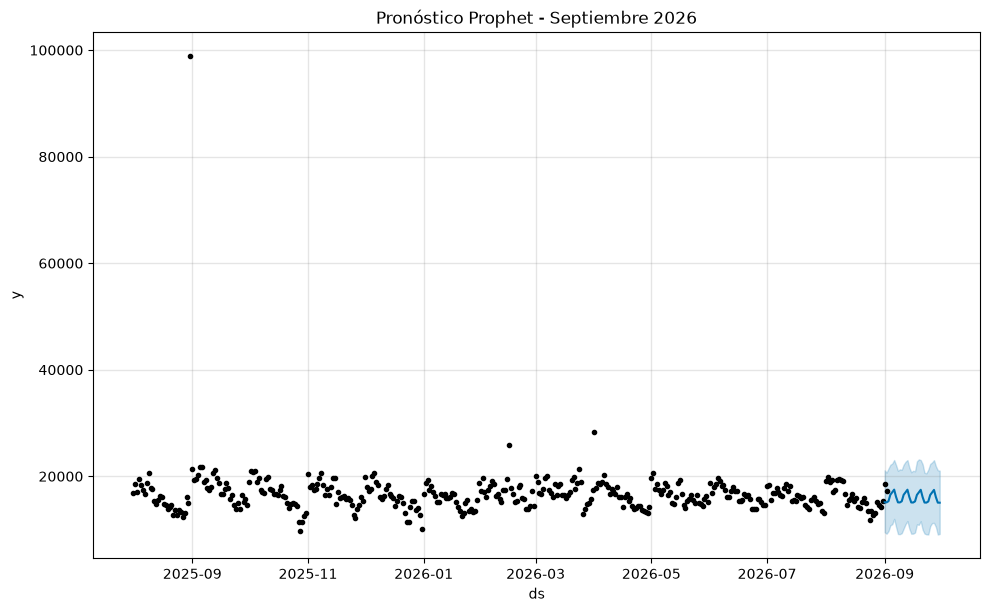

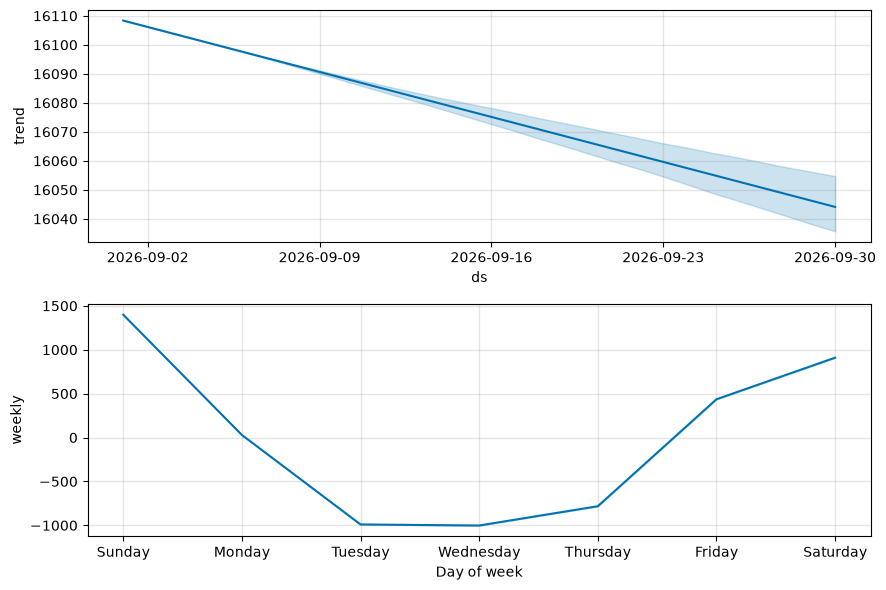

In [179]:
model.plot(forecast_sep)
plt.title("Pronóstico Prophet - Septiembre 2026")
plt.show()

model.plot_components(forecast_sep)
plt.show()


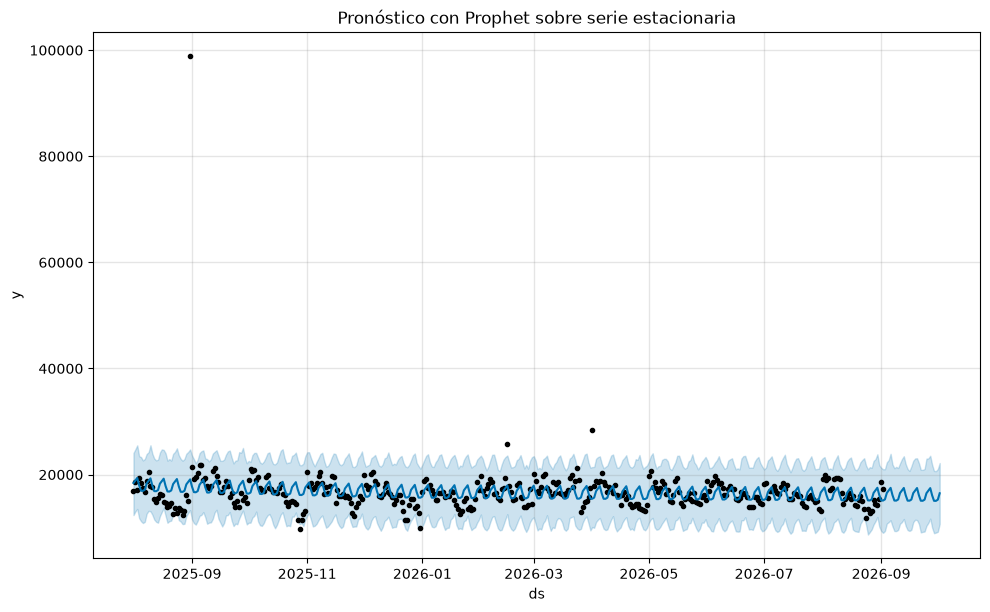

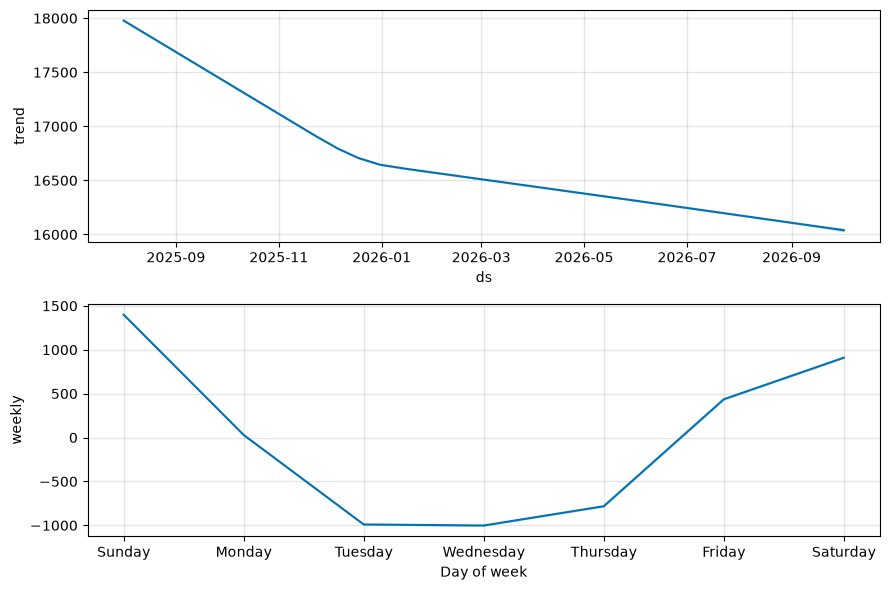

In [180]:

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)


model.plot(forecast)
plt.title("Pronóstico con Prophet sobre serie estacionaria")
plt.show()

model.plot_components(forecast)
plt.show()

# REACTIVADOS

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [182]:
df_reactivados = pd.read_excel("pronostico.xlsx", sheet_name='REACTIVADOS')
df_reactivados.head()

,DIA,MES,ANIO,REACTIVADOS
0,1,8,2025,13726
1,2,8,2025,11359
2,3,8,2025,8054
3,4,8,2025,9358
4,5,8,2025,8602


In [183]:
df_reactivados['FECHA'] = pd.to_datetime(df_reactivados['ANIO'].astype(str) + '-' +
                             df_reactivados['MES'].astype(str) + '-' +
                             df_reactivados['DIA'].astype(str))


In [184]:
df_reactivados.head()

,DIA,MES,ANIO,REACTIVADOS,FECHA
0,1,8,2025,13726,2025-08-01
1,2,8,2025,11359,2025-08-02
2,3,8,2025,8054,2025-08-03
3,4,8,2025,9358,2025-08-04
4,5,8,2025,8602,2025-08-05


In [185]:
df_reactivados.head()

,DIA,MES,ANIO,REACTIVADOS,FECHA
0,1,8,2025,13726,2025-08-01
1,2,8,2025,11359,2025-08-02
2,3,8,2025,8054,2025-08-03
3,4,8,2025,9358,2025-08-04
4,5,8,2025,8602,2025-08-05


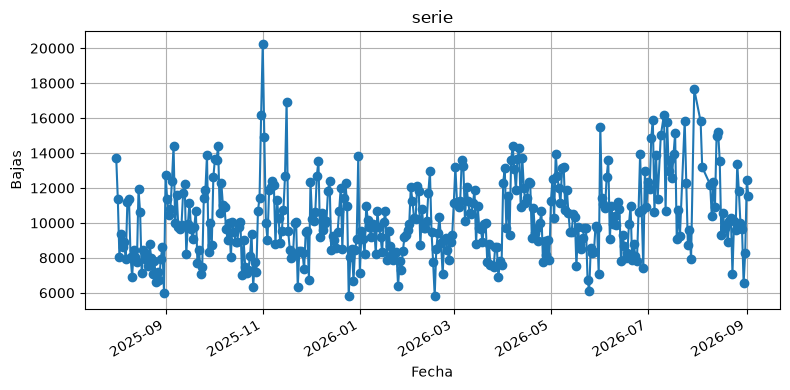

In [186]:
plt.figure(figsize=(8, 4))
df_reactivados.set_index(df_reactivados['FECHA'])['REACTIVADOS'].plot(
    marker='o', linestyle='-', label='REACTIVADOS')
plt.title('serie')
plt.xlabel('Fecha')
plt.ylabel('Bajas')
plt.grid(True)
plt.tight_layout()
plt.show()

In [187]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

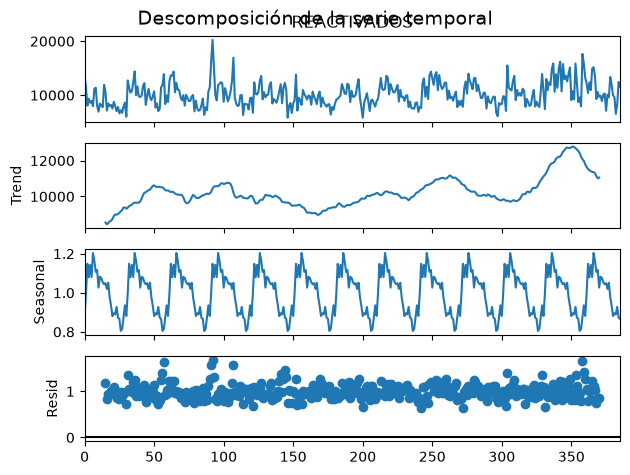

In [188]:
periodo = 30
resultado = seasonal_decompose(df_reactivados['REACTIVADOS'], model='multiplicative', period=periodo)
resultado.plot()
plt.suptitle("Descomposición de la serie temporal", fontsize=14)
plt.show()

In [189]:
df_prophet = df_reactivados[['FECHA', 'REACTIVADOS']].copy()
df_prophet = df_prophet.rename(columns={
    'FECHA': 'ds',
    'REACTIVADOS': 'y'
})
df_prophet = df_prophet.sort_values('ds')

In [190]:
from prophet import Prophet

In [191]:
df_prophet

,ds,y
0,2025-08-01,13726
1,2025-08-02,11359
2,2025-08-03,8054
3,2025-08-04,9358
4,2025-08-05,8602
...,...,...
381,2026-08-29,9649
382,2026-08-30,6539
383,2026-08-31,8303
384,2026-09-01,12443


In [192]:
import pandas as pd
from prophet import Prophet


df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], errors='coerce')
df_prophet['y'] = pd.to_numeric(df_prophet['y'], errors='coerce')

df_prophet = df_prophet.dropna(subset=['ds', 'y'])


df_prophet = df_prophet.sort_values('ds')

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(df_prophet)



16:59:32 - cmdstanpy - INFO - Chain [1] start processing
16:59:32 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
future_sep = pd.DataFrame({
    'ds': pd.date_range(
        start='2026-09-01',
        end='2026-09-30',
        freq='D'
    )
})
forecast_sep =model.predict(future_sep)

In [194]:
print(forecast_sep[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

           ds          yhat    yhat_lower    yhat_upper
0  2026-09-01  10753.365099   8252.975838  13381.824359
1  2026-09-02  11006.775103   8534.047353  13596.016702
2  2026-09-03  11048.735294   8537.710578  13647.680492
3  2026-09-04  12311.377178   9786.335294  14836.020358
4  2026-09-05  12650.483198  10167.568494  15367.277115
5  2026-09-06   9785.601316   7331.870638  12297.741090
6  2026-09-07  11604.409877   9250.494527  14285.702948
7  2026-09-08  10796.987898   8282.786719  13258.701677
8  2026-09-09  11050.397902   8599.219791  13677.936646
9  2026-09-10  11092.358094   8500.864973  13554.041657
10 2026-09-11  12354.999977   9881.538554  14802.383247
11 2026-09-12  12694.105997  10094.988859  15372.880075
12 2026-09-13   9829.224115   7328.715402  12375.258830
13 2026-09-14  11648.032676   9155.436958  14201.059552
14 2026-09-15  10840.610697   8545.738392  13283.723704
15 2026-09-16  11094.020701   8656.347786  13494.535897
16 2026-09-17  11135.980893   8787.723942  13598

In [195]:
forecast_sep['yhat_lower'].sum()

np.float64(265527.03383089206)

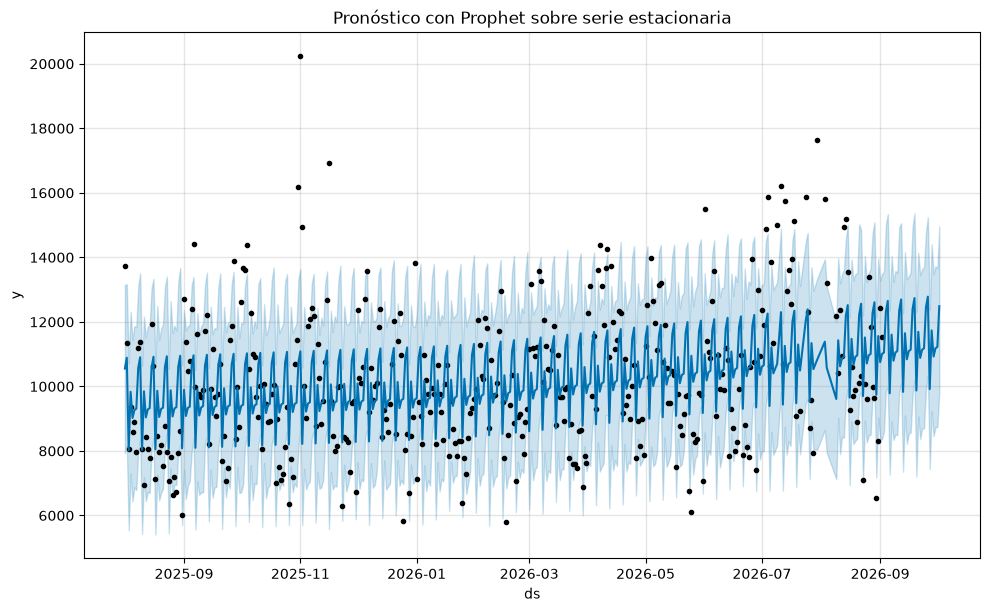

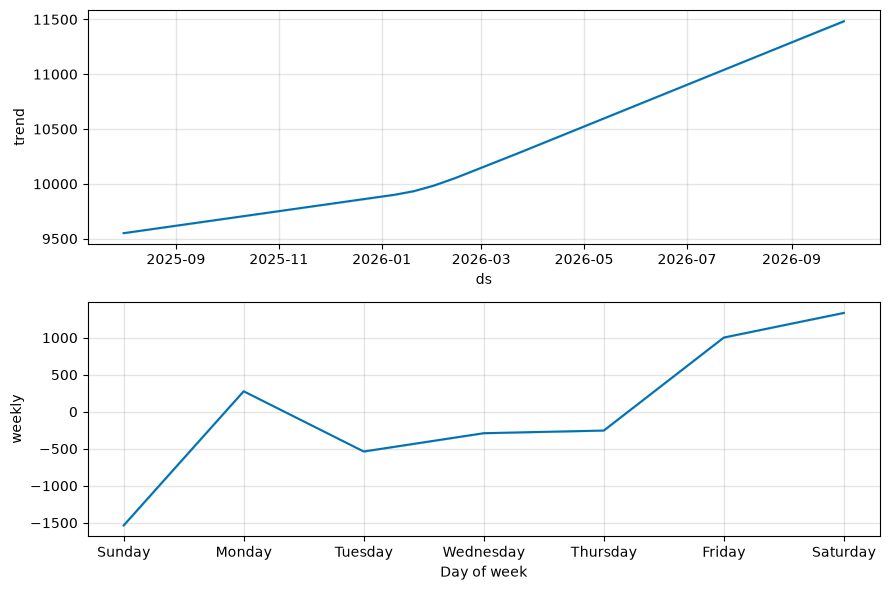

In [196]:

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)


model.plot(forecast)
plt.title("Pronóstico con Prophet sobre serie estacionaria")
plt.show()

model.plot_components(forecast)
plt.show()

In [197]:
df_adj = forecast_sep[['ds', 'yhat_lower']].copy()
n = len(df_adj)
pesos = np.linspace(1.07, 0.93, n)  

df_adj['yhat_ponderado'] = df_adj['yhat_lower'] * pesos

objetivo = 311_000
factor = objetivo / df_adj['yhat_ponderado'].sum()
df_adj['yhat_ajustado'] = df_adj['yhat_ponderado'] * factor

#print(df_adj[['ds', 'yhat_lower', 'yhat_ajustado']])
print("Suma ajustada:", df_adj['yhat_ajustado'].sum())
print("Suma ajustada:", df_adj['yhat_ponderado'].sum())

print("Suma ajustada:", df_adj['yhat_lower'].sum())
df_adj['yhat_ajustado'].head(30)

Suma ajustada: 311000.0
Suma ajustada: 265512.9346303072
Suma ajustada: 265527.03383089206


0     10343.536647
1     10647.549430
2     10603.842215
3     12099.296768
4     12513.139010
5      8981.811003
6     11279.887593
7     10053.045845
8     10388.483892
9     10221.594800
10    11825.865334
11    12024.231382
12     8687.857138
13    10801.581375
14    10033.936166
15    10114.859130
16    10218.679513
17    11636.182190
18    11604.472262
19     8371.461214
20    10280.479108
21     9312.426682
22     9673.265228
23     9674.131965
24    11325.968177
25    11488.110818
26     8121.240333
27    10188.970036
28     9310.971313
29     9173.123435
Name: yhat_ajustado, dtype: float64

In [198]:
m=df_adj[['yhat_ajustado']]
m.to_excel('pron.xlsx')
